#  Import Libraries

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [47]:
data = {
    "Name": ["Sumit","Rahul","Aman","Ritika","Priya"],
    "Math": [85,78,92,95,70],
    "Science":[90,88,85,91,72],
    "English":[80,75,89,94,68]
}

df = pd.DataFrame(data)

df

,Name,Math,Science,English
0,Sumit,85,90,80
1,Rahul,78,88,75
2,Aman,92,85,89
3,Ritika,95,91,94
4,Priya,70,72,68


In [48]:
df.to_csv("Student_perfomance.csv",index= False)



#  Basic infomation

In [49]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     5 non-null      object
 1   Math     5 non-null      int64 
 2   Science  5 non-null      int64 
 3   English  5 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 292.0+ bytes


,Math,Science,English
count,5.000000,5.000000,5.000000
mean,84.000000,85.200000,81.200000
std,10.222524,7.726578,10.473777
min,70.000000,72.000000,68.000000
25%,78.000000,85.000000,75.000000
50%,85.000000,88.000000,80.000000
75%,92.000000,90.000000,89.000000
max,95.000000,91.000000,94.000000


#  Missing Values

In [51]:
df.isnull().sum()

Name       0
Math       0
Science    0
English    0
dtype: int64

In [52]:
df

,Name,Math,Science,English
0,Sumit,85,90,80
1,Rahul,78,88,75
2,Aman,92,85,89
3,Ritika,95,91,94
4,Priya,70,72,68


#  Create Total Marks

In [54]:
df["Total"] = (df["Math"] + df["Science"] + df["English"])

df

,Name,Math,Science,English,Total
0,Sumit,85,90,80,255
1,Rahul,78,88,75,241
2,Aman,92,85,89,266
3,Ritika,95,91,94,280
4,Priya,70,72,68,210


# Create Percentage

In [55]:
df["Percentage"] = df["Total"] /3 
df

,Name,Math,Science,English,Total,Percentage
0,Sumit,85,90,80,255,85.000000
1,Rahul,78,88,75,241,80.333333
2,Aman,92,85,89,266,88.666667
3,Ritika,95,91,94,280,93.333333
4,Priya,70,72,68,210,70.000000


# Find Top Student

In [57]:
df[df["Percentage"] == df["Percentage"].max()]

,Name,Math,Science,English,Total,Percentage
3,Ritika,95,91,94,280,93.333333


#  Find Lowest Student

In [59]:
df[df["Percentage"] == df["Percentage"].min()]

,Name,Math,Science,English,Total,Percentage
4,Priya,70,72,68,210,70.0


#  Add Grage Column

In [60]:
def grade(p):
    
    if p >= 90:
        return "A"
    
    elif p >= 80:
        return "B"
    
    elif p >= 70:
        return "C"
    
    else:
        return "D"
    
df["Grade"] = df["Percentage"].apply(grade)

df

,Name,Math,Science,English,Total,Percentage,Grade
0,Sumit,85,90,80,255,85.000000,B
1,Rahul,78,88,75,241,80.333333,B
2,Aman,92,85,89,266,88.666667,B
3,Ritika,95,91,94,280,93.333333,A
4,Priya,70,72,68,210,70.000000,C


#  Grade Distribution Chart

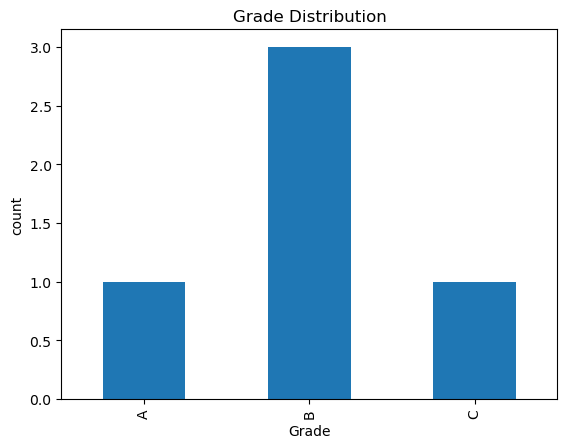

In [61]:
order = ["A","B","C"]

df["Grade"].value_counts().reindex(order).plot(kind="bar")

plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("count")
plt.show()

#  Perecntage Chart

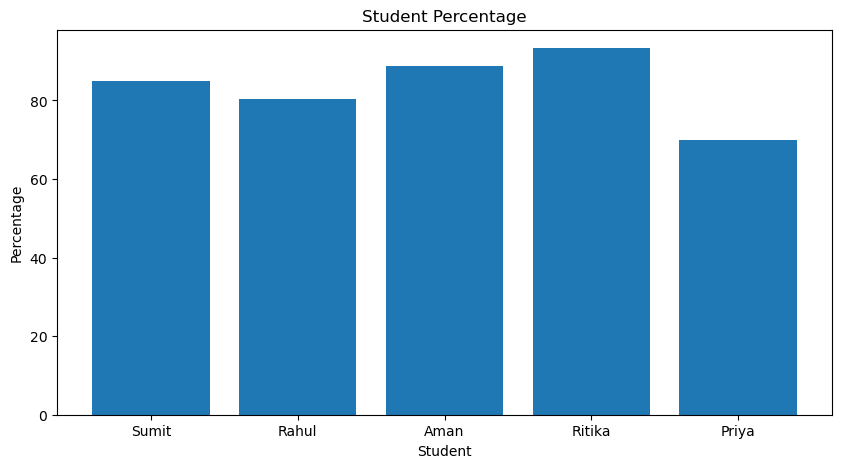

In [66]:
plt.figure(figsize=(10,5))

plt.bar(
    df["Name"],
    df["Percentage"]
)

plt.title("Student Percentage")
plt.xlabel("Student")
plt.ylabel("Percentage")

plt.show()

In [75]:
print("Average Percentage :",
      df["Percentage"].mean().round(2))

print("Highest Percent :",
      df["Percentage"].max())

print("Lowest Percentage :",
      df["Percentage"].min())

Average Percentage : 83.47
Highest Percent : 93.33333333333333
Lowest Percentage : 70.0


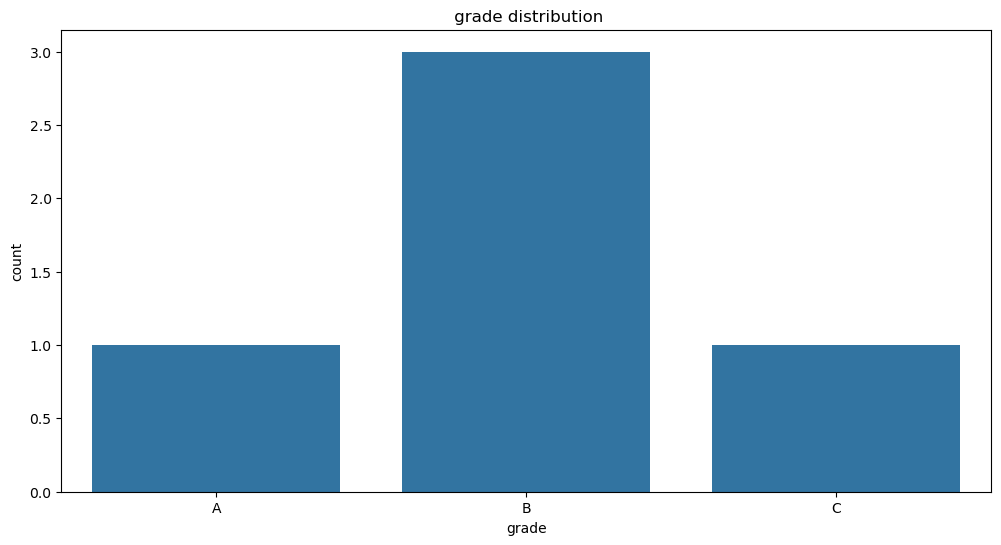

In [62]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Grade",
    order=["A","B","C"]
)

plt.title(" grade distribution")
plt.xlabel("grade")
plt.ylabel("count")
plt.show()

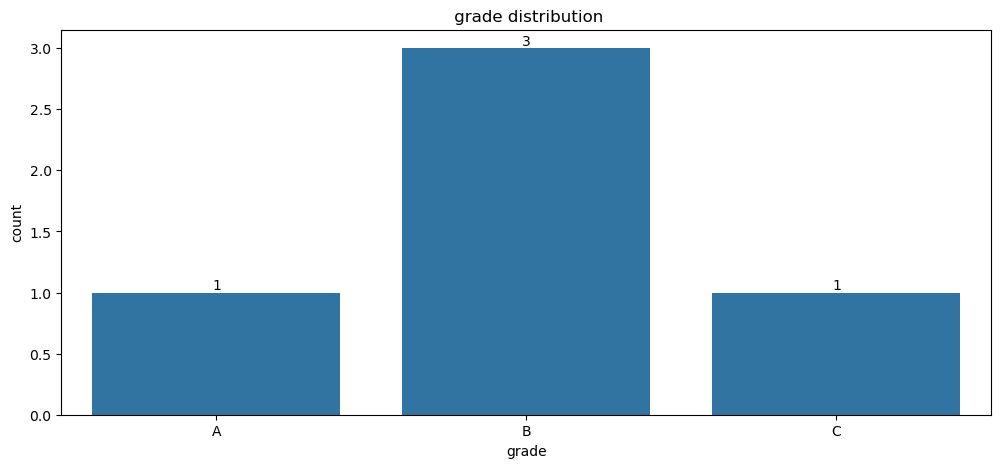

In [63]:
plt.figure(figsize=(12,5))

ax = sns.countplot(
    data=df,
    x="Grade",
    order=["A","B","C"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(" grade distribution")
plt.xlabel("grade")
plt.ylabel("count")
plt.show()



# Heatmap chart

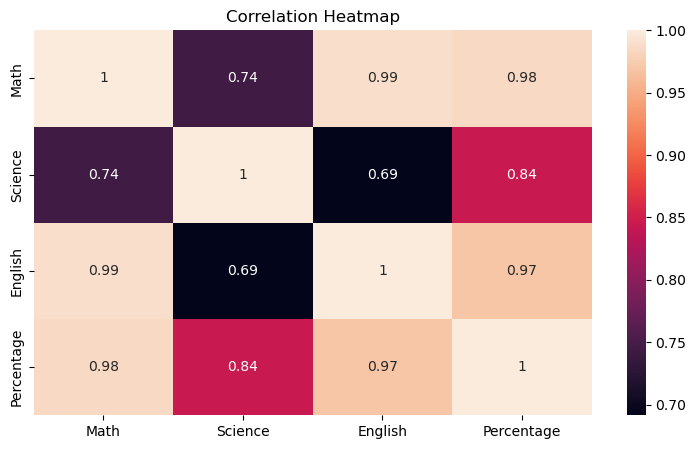

In [64]:
plt.figure(figsize=(9,5))

sns.heatmap(
    df[["Math","Science","English","Percentage"]].corr(),
    annot=True,
    # cmap="coolwarm",
)

plt.title("Correlation Heatmap")
plt.show()

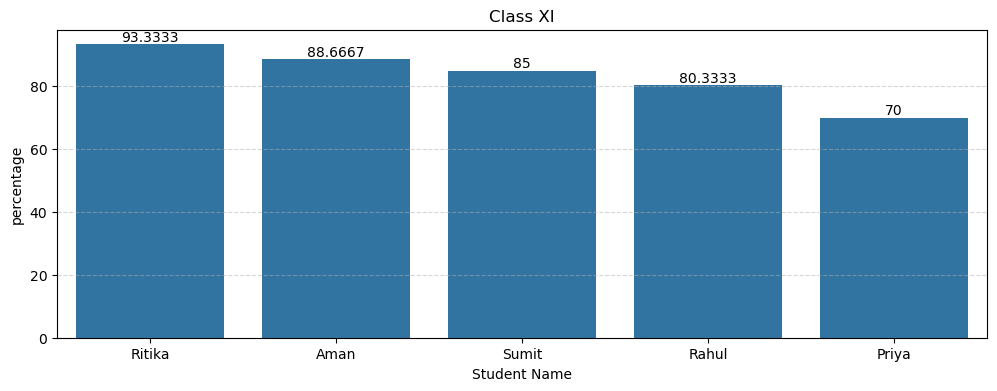

In [65]:
df_sorted = df.sort_values(
    by="Percentage",
    ascending=False
)


plt.figure(figsize=(12,4))

ax = sns.barplot(
    data=df_sorted,
    x="Name",
    y="Percentage"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Class XI")
plt.xlabel("Student Name")
plt.ylabel("percentage")

plt.grid(axis="y",linestyle="--", alpha=0.5)
plt.show()

#  Box chart

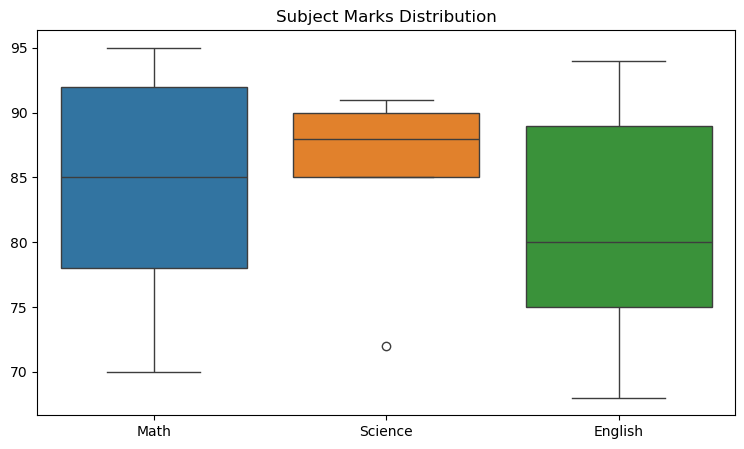

In [77]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df[["Math","Science","English"]]
)

plt.title("Subject Marks Distribution")
plt.show()


# Histogram chart

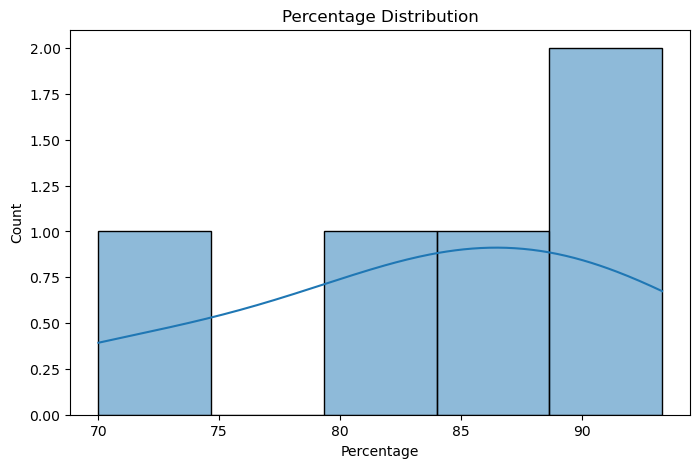

In [80]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Percentage"],
    bins=5,
    kde=True
)

plt.title("Percentage Distribution")
plt.xlabel("Percentage")
plt.ylabel("Count")

plt.show()

#  Final EDA Report Summary

1. Total Students: 5

2. Top Performer:
   Ritika (93.33%)

3. Lowest Performer:
   Priya (70.00%)

4. Most students scored between 80–90%.

5. Grade Distribution:
   A = 1
   B = 3
   C = 1

6. Math showed the highest median score.

7. Science showed the widest spread of marks.

8. Student performance was generally good, with most students achieving Grade B.

<!-- 1. Total Students: 5

2. Top Performer:
   Ritika (93.33%)

3. Lowest Performer:
   Priya (70.00%)

4. Most students scored between 80–90%.

5. Grade Distribution:
   A = 1
   B = 3
   C = 1

6. Math showed the highest median score.

7. Science showed the widest spread of marks.

8. Student performance was generally good, with most students achieving Grade B. -->